# S1 Backtest — N grid search (IS)

Signal: **05 slim-ffill Ridge** (`s1_linear_slim_ffill_is_predictions.parquet`).

Timing fixed to **`mon_open_mon_open`** (enter Monday open, roll at next Monday open).
Grid `N` on **research IS only**; select `N*` by **IS net Sharpe** (Alpaca-representative costs).

## Costs (Alpaca)

| Component | Open fill |
|---|---|
| Commission | 0 bps |
| Regulatory buffer | 0.5 bps |
| Half-spread | 5 bps |
| Open slippage | 10 bps |
| Short borrow | 0 |
| **One-way** | **15.5 bps** |


## 0. Imports & Config


In [1]:
import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore")

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from backtest.s1_equities.costs import DEFAULT_COSTS, cost_summary
from backtest.s1_equities.report import plot_n_grid
from backtest.s1_equities.runner import run_backtest, summarize_periods
from backtest.s1_equities.signals import (
    TIMING_MON_OPEN_MON_OPEN,
    default_backtest_paths,
    is_mask_from_preds,
    load_ohlc_panels,
    load_predictions,
    score_matrix,
)

PATHS = default_backtest_paths(ROOT)
ART = PATHS["artifacts"]
os.makedirs(ART, exist_ok=True)

N_GRID = [5, 10, 15, 20, 25, 30]
TIMING_MODE = TIMING_MON_OPEN_MON_OPEN

print(f"ROOT={ROOT}")
print(f"predictions={PATHS['predictions']}")
print(f"artifacts={ART}")
display(pd.Series(cost_summary(DEFAULT_COSTS), name="bps").to_frame())


ROOT=c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio
predictions=c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\03_models\s1_equities\model_artifacts\s1_linear_slim_ffill_is_predictions.parquet
artifacts=c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\04_backtest\s1_equities\artifacts


,bps
commission_bps,0.0
regulatory_bps,0.5
half_spread_bps,5.0
open_slippage_bps,10.0
close_slippage_bps,5.0
short_borrow_bps,0.0
open_one_way_bps,15.5
close_one_way_bps,10.5


## 1. Load scores & prices


In [2]:
preds = load_predictions(PATHS["predictions"])
scores = score_matrix(preds)
is_mask = is_mask_from_preds(preds)
opens, highs, lows, closes = load_ohlc_panels(PATHS["features"], tickers=list(scores.columns))

print(f"scores={scores.shape}  opens={opens.shape}  closes={closes.shape}")
print(
    f"IS entry dates={int(is_mask.sum())}  "
    f"non-IS={int((~is_mask).sum())}  "
    f"span={scores.index.min().date()} -> {scores.index.max().date()}"
)
preds.head()


scores=(592, 68)  opens=(4165, 68)  closes=(4165, 68)
IS entry dates=411  non-IS=181  span=2015-03-23 -> 2026-07-20


,date,ticker,fwd_ret_5,is_research_is,score,cs_rank,feature_date
0,2015-03-23,AAPL,-0.024150,True,0.519832,0.725,2015-03-20
1,2015-03-23,ABT,-0.009901,True,0.483406,0.125,2015-03-20
2,2015-03-23,ADBE,-0.046687,True,0.501119,0.375,2015-03-20
3,2015-03-23,AMAT,-0.048053,True,0.520712,0.750,2015-03-20
4,2015-03-23,AMD,-0.028470,True,0.521422,0.775,2015-03-20


## 2. IS N grid (net of costs)


In [3]:
rows = []
for n in N_GRID:
    res = run_backtest(
        scores,
        opens,
        closes,
        n=n,
        timing_mode=TIMING_MODE,
        costs=DEFAULT_COSTS,
        date_mask=is_mask,
    )
    sm = summarize_periods(res.period_returns)
    sm_g = summarize_periods(res.period_returns_gross)
    rows.append(
        {
            "n": n,
            "timing_mode": TIMING_MODE,
            "sharpe": sm["sharpe"],
            "cagr": sm["cagr"],
            "total_return": sm["total_return"],
            "max_drawdown": sm["max_drawdown"],
            "vol": sm["vol"],
            "win_rate": sm["win_rate"],
            "mean_turnover": float(res.turnover.mean()) if len(res.turnover) else np.nan,
            "n_periods": sm["n_periods"],
            "sharpe_gross": sm_g["sharpe"],
            "total_return_gross": sm_g["total_return"],
        }
    )
    print(
        f"N={n:>2}  sharpe={sm['sharpe']:.3f}  cagr={sm['cagr']:.3%}  "
        f"dd={sm['max_drawdown']:.3%}  periods={sm['n_periods']}"
    )

grid_df = pd.DataFrame(rows).sort_values("n").reset_index(drop=True)
display(grid_df)

best = grid_df.sort_values(["sharpe", "cagr"], ascending=False).iloc[0]
N_STAR = int(best["n"])
print(f"Suggested N_STAR={N_STAR}  (IS net Sharpe={best['sharpe']:.4f})")
print("Copy this integer into N_STAR in notebooks 02–06.")


N= 5  sharpe=0.994  cagr=14.416%  dd=-38.366%  periods=410
N=10  sharpe=0.654  cagr=6.992%  dd=-32.140%  periods=410
N=15  sharpe=0.765  cagr=7.016%  dd=-26.375%  periods=410
N=20  sharpe=0.726  cagr=5.727%  dd=-24.785%  periods=410
N=25  sharpe=0.440  cagr=3.257%  dd=-21.876%  periods=256
N=30  sharpe=0.165  cagr=0.943%  dd=-21.005%  periods=220


,n,timing_mode,sharpe,cagr,total_return,max_drawdown,vol,win_rate,mean_turnover,n_periods,sharpe_gross,total_return_gross
0,5,mon_open_mon_open,0.994024,0.144162,1.891690,-0.383660,0.146448,0.600000,0.225366,410,1.118490,2.335954
1,10,mon_open_mon_open,0.653983,0.069925,0.703882,-0.321404,0.113230,0.563415,0.163537,410,0.770351,0.890229
2,15,mon_open_mon_open,0.765498,0.070164,0.706892,-0.263752,0.094487,0.592683,0.128130,410,0.874607,0.851468
3,20,mon_open_mon_open,0.725801,0.057266,0.551255,-0.247852,0.081331,0.585366,0.111951,410,0.836948,0.665531
4,25,mon_open_mon_open,0.440496,0.032573,0.170934,-0.218760,0.080064,0.601562,0.104453,256,0.545466,0.220440
5,30,mon_open_mon_open,0.164880,0.009433,0.040523,-0.210047,0.073147,0.568182,0.093409,220,0.267625,0.074176


Suggested N_STAR=5  (IS net Sharpe=0.9940)
Copy this integer into N_STAR in notebooks 02–06.


## 3. Plots


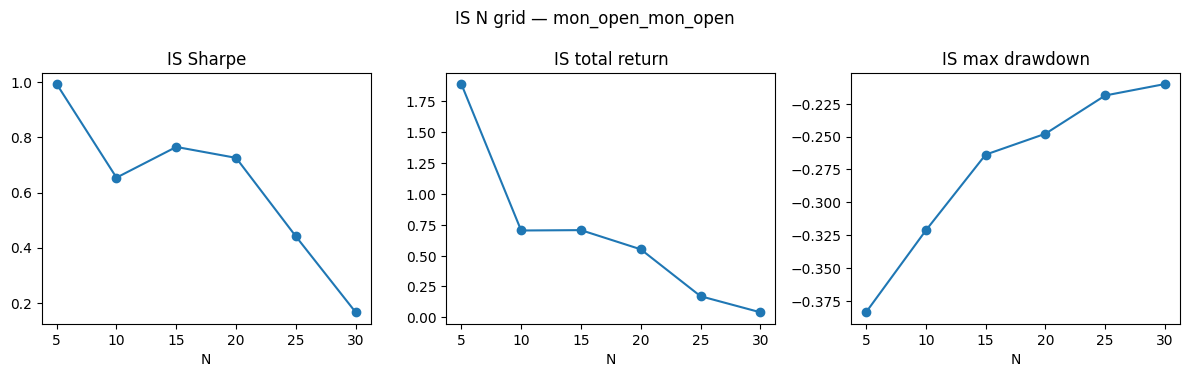

Suggested N_STAR=5 — set N_STAR=5 in 02_timing_bakeoff / 03_weighting_bakeoff / 05_stop_bakeoff / 06_pct_stop_bakeoff / 07_oos_tearsheet


In [4]:
fig = plot_n_grid(grid_df, title=f"IS N grid — {TIMING_MODE}")
plt.show()

print(f"Suggested N_STAR={N_STAR} — set N_STAR={N_STAR} in 02_timing_bakeoff / 03_weighting_bakeoff / 05_stop_bakeoff / 06_pct_stop_bakeoff / 08_oos_tearsheet")
